In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [44]:
stocks = {}
for ticker, fname in {
    'NVDA': 'data/NVDA.csv',
    'MSFT': 'data/MSFT.csv',
    'GOOGL': 'data/GOOGL.csv',
    'AMZN': 'data/AMZN.csv',
    'META': 'data/META.csv',
}.items():
    df = pd.read_csv(fname)
    df['Date'] = pd.to_datetime(df['Date'], utc=True).dt.tz_localize(None)
    stocks[ticker] = df
    print(f"{ticker}: {len(df)}lens, {df['Date'].min()} to {df['Date'].max()}")

NVDA: 1254lens, 2021-01-04 05:00:00 to 2025-12-30 05:00:00
MSFT: 1254lens, 2021-01-04 05:00:00 to 2025-12-30 05:00:00
GOOGL: 1254lens, 2021-01-04 05:00:00 to 2025-12-30 05:00:00
AMZN: 1254lens, 2021-01-04 05:00:00 to 2025-12-30 05:00:00
META: 1254lens, 2021-01-04 05:00:00 to 2025-12-30 05:00:00


In [45]:
news = {}
for ticker, fname in {
    'NVDA': 'data/NVIDIA2021_2025.xlsx',
    'META': 'data/meta2021-2025.xlsx',
    'MSFT': 'data/MSFT2021-2025.xlsx',
    'AMZN': 'data/AMA2021-2025.xlsx',
    'GOOGL': 'data/GOO2021-2025.xlsx',
}.items():
    df = pd.read_excel(fname)
    df.columns = ['Date', 'Title', 'Summary']
    df['Date'] = pd.to_datetime(df['Date'])
    df['Ticker'] = ticker
    news[ticker] = df
    print(f"{ticker}: {len(df)} articles, {df['Date'].min().date()} to {df['Date'].max().date()}")

fomc = pd.read_csv('data/fomc_statements.csv')
fomc['Date'] = pd.to_datetime(fomc['Date'])
print(f"\nFOMC: {len(fomc)} meetings")

NVDA: 2434 articles, 2021-01-06 to 2025-09-30
META: 2411 articles, 2021-05-19 to 2025-12-31
MSFT: 2655 articles, 2021-01-06 to 2025-12-22
AMZN: 3982 articles, 2021-01-04 to 2025-12-31
GOOGL: 1624 articles, 2021-01-04 to 2025-12-24

FOMC: 36 meetings


In [46]:
phase_map = {
    'Phase 1: QE/零利率': 'Phase 1: QE/Zero Rate',
    'Phase 2: 激进加息': 'Phase 2: Aggressive Hiking',
    'Phase 3: 高利率维持': 'Phase 3: High Rate Maintenance',
}
fomc['Monetary_Phase'] = fomc['Monetary_Phase'].map(phase_map)

In [47]:
# Build equal-weight portfolio daily return
returns = pd.DataFrame()

for ticker, df in stocks.items():
    tmp = df[['Date', 'Daily_Return']].copy()
    tmp['Date'] = tmp['Date'].dt.date
    tmp = tmp.rename(columns={'Daily_Return': ticker})
    if returns.empty:
        returns = tmp
    else:
        returns = returns.merge(tmp, on='Date', how='inner')

returns['Date'] = pd.to_datetime(returns['Date'])
returns['Portfolio'] = returns[['NVDA','META','MSFT','AMZN','GOOGL']].mean(axis=1) * 100

print(returns.shape)
print(returns.head())

(1254, 7)
        Date      NVDA      MSFT     GOOGL      AMZN      META  Portfolio
0 2021-01-04       NaN       NaN       NaN       NaN       NaN        NaN
1 2021-01-05  0.022210  0.000965  0.008064  0.010004  0.007548   0.975833
2 2021-01-06 -0.058953 -0.025929 -0.009868 -0.024897 -0.028269  -2.958316
3 2021-01-07  0.057830  0.028457  0.029869  0.007577  0.020622   2.887103
4 2021-01-08 -0.005040  0.006093  0.013239  0.006496 -0.004354   0.328676


In [48]:
returns = returns.dropna().reset_index(drop=True)

print(f"Total trading days: {len(returns)}")
print(f"Date range: {returns['Date'].min().date()} to {returns['Date'].max().date()}")
print(f"\nPortfolio Daily Return Stats:")
print(returns['Portfolio'].describe().round(4))

Total trading days: 1253
Date range: 2021-01-05 to 2025-12-30

Portfolio Daily Return Stats:
count    1253.0000
mean        0.1271
std         1.9293
min        -9.3084
25%        -0.8457
50%         0.1435
75%         1.1939
max        13.0542
Name: Portfolio, dtype: float64


In [49]:
import os
os.makedirs('output', exist_ok=True)

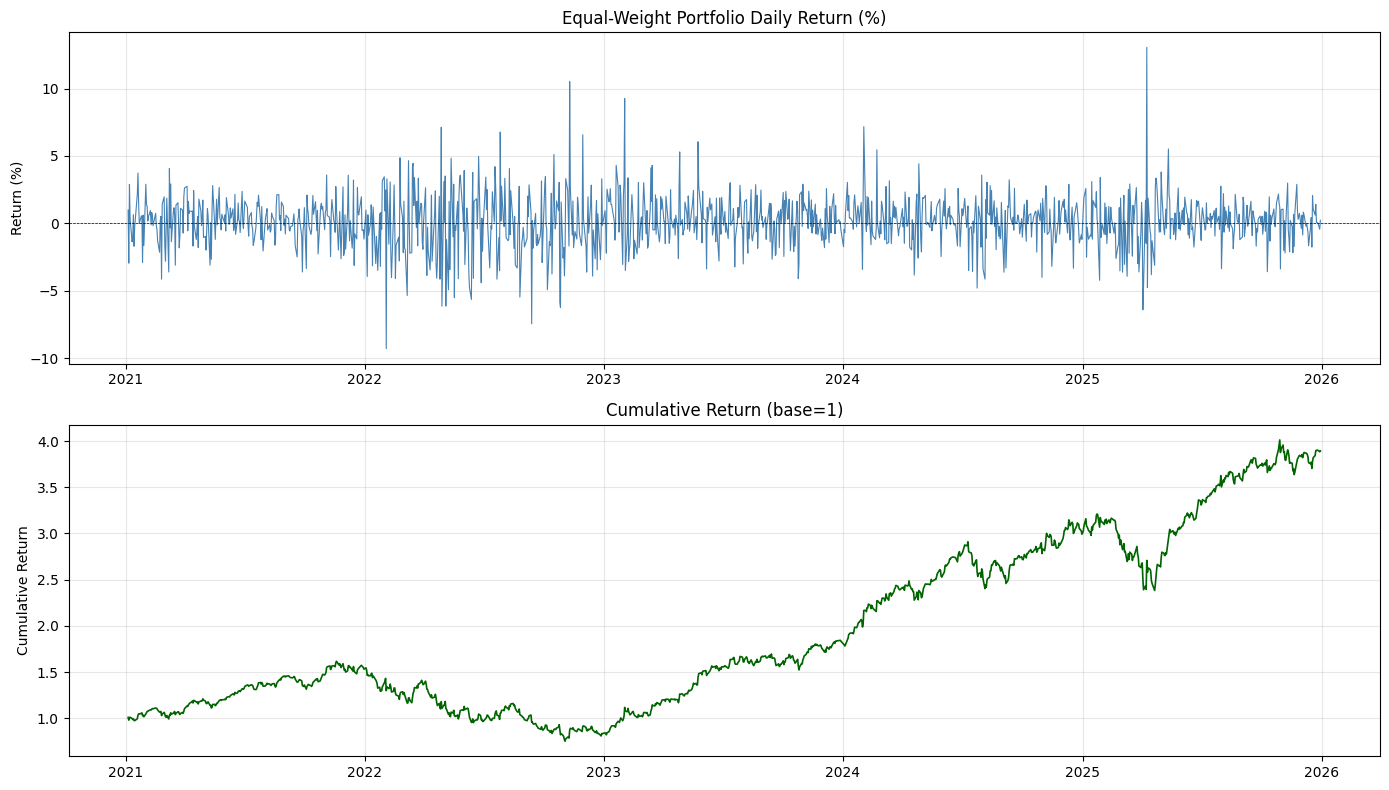

In [50]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Daily return
axes[0].plot(returns['Date'], returns['Portfolio'], linewidth=0.8, color='steelblue')
axes[0].axhline(0, color='black', linewidth=0.5, linestyle='--')
axes[0].set_title('Equal-Weight Portfolio Daily Return (%)')
axes[0].set_ylabel('Return (%)')

# Cumulative return
returns['Cumulative'] = (1 + returns['Portfolio'] / 100).cumprod()
axes[1].plot(returns['Date'], returns['Cumulative'], linewidth=1.2, color='darkgreen')
axes[1].set_title('Cumulative Return (base=1)')
axes[1].set_ylabel('Cumulative Return')

for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('output/portfolio_return.png', dpi=150)
plt.show()

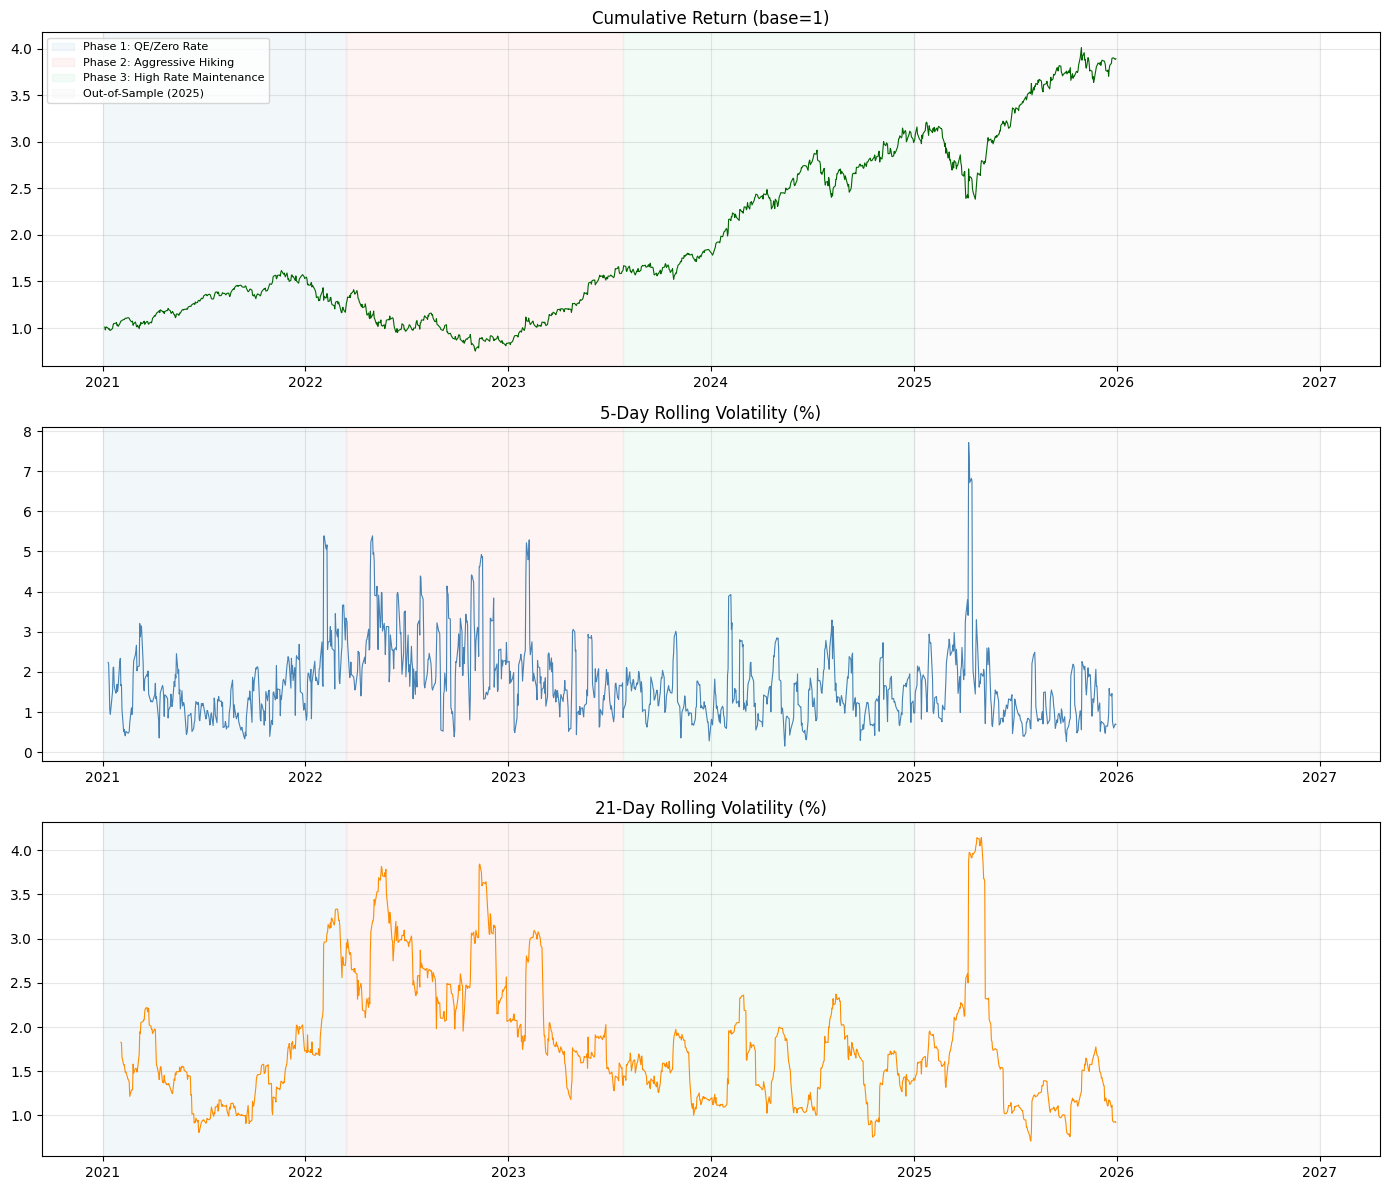

In [51]:
phase_colors = {
    'Phase 1: QE/Zero Rate': '#d4e6f1',
    'Phase 2: Aggressive Hiking': '#fadbd8',
    'Phase 3: High Rate Maintenance': '#d5f5e3',
    'Out-of-Sample (2025)': '#f2f3f4',
}

phase_bounds = {
    'Phase 1: QE/Zero Rate': ('2021-01-01', '2022-03-15'),
    'Phase 2: Aggressive Hiking': ('2022-03-16', '2023-07-26'),
    'Phase 3: High Rate Maintenance': ('2023-07-27', '2024-12-31'),
    'Out-of-Sample (2025)': ('2025-01-01', '2026-12-31'),
}

returns['Vol_5'] = returns['Portfolio'].rolling(5).std()
returns['Vol_21'] = returns['Portfolio'].rolling(21).std()

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

plots = [
    (returns['Cumulative'], 'darkgreen', 'Cumulative Return (base=1)'),
    (returns['Vol_5'], 'steelblue', '5-Day Rolling Volatility (%)'),
    (returns['Vol_21'], 'darkorange', '21-Day Rolling Volatility (%)'),
]

for ax, (series, color, title) in zip(axes, plots):
    for phase, (start, end) in phase_bounds.items():
        ax.axvspan(pd.Timestamp(start), pd.Timestamp(end),
                   alpha=0.3, color=phase_colors[phase], label=phase)
    ax.plot(returns['Date'], series, linewidth=0.8, color=color)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

axes[0].legend(loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig('output/portfolio_phases.png', dpi=150)
plt.show()

## Key Observation: Volatility Driver Analysis

The three-phase volatility pattern reveals an important insight: 
**it is the rate of change in interest rates, not the absolute level, that drives market volatility.**

- **Phase 1 (QE/Zero Rate)**: Low and stable rates. Market had fully priced in the environment, resulting in low volatility.
- **Phase 2 (Aggressive Hiking)**: Rapid rate increases from 0% to 5.25%. Each FOMC meeting introduced fresh uncertainty, producing persistently elevated volatility with frequent spikes.
- **Phase 3 (High Rate Maintenance)**: Rates remained high but stable. Once the market re-priced to the new level, volatility subsided despite the tight environment.
- **2025 (DeepSeek Shock)**: Minimal rate change, yet the largest volatility spike in the entire sample. This confirms that the core driver is **informational uncertainty** — whether from monetary policy shifts or narrative shocks.

This reframes RQ2: rather than asking whether high rates suppress news-driven shocks, we should ask whether **rapid rate changes amplify the transmission of narrative shocks** into price movements. The DeepSeek event serves as a natural out-of-sample stress test, demonstrating that AI narrative shocks can independently generate extreme volatility under a stable monetary environment.

In [53]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

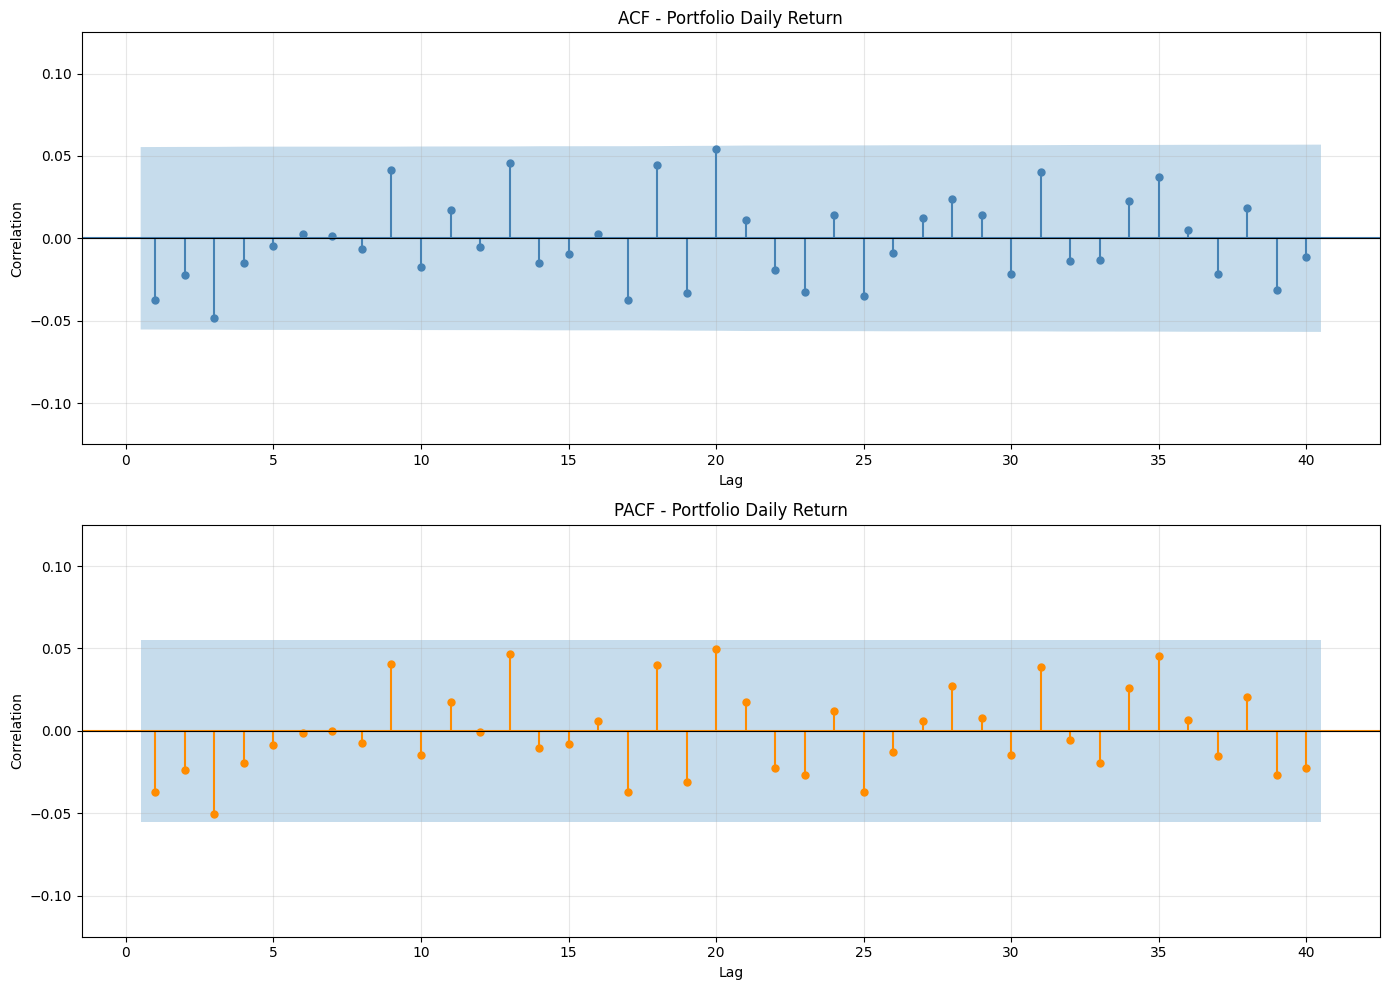

In [54]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

plot_acf(returns['Portfolio'].dropna(), lags=40, zero=False,
         ax=axes[0], title='ACF - Portfolio Daily Return',
         alpha=0.05, color='steelblue', vlines_kwargs={'colors': 'steelblue'})

plot_pacf(returns['Portfolio'].dropna(), lags=40, zero=False,
          ax=axes[1], title='PACF - Portfolio Daily Return',
          alpha=0.05, color='darkorange', vlines_kwargs={'colors': 'darkorange'})

for ax in axes:
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_ylim(-0.125, 0.125)
    ax.set_xlabel('Lag')
    ax.set_ylabel('Correlation')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('output/acf_pacf_return.png', dpi=150)
plt.show()

## ACF & PACF Analysis - Portfolio Daily Return

Both the ACF and PACF plots show no significant autocorrelation across all 40 lags, 
with all coefficients remaining within the 95% confidence band (±1.96/√n ≈ ±0.055, n=1253).

**Key finding:** The equal-weight portfolio daily return series follows a random walk process, 
consistent with the Efficient Market Hypothesis (EMH) under normal conditions.

**Implication for DNEM:** The absence of autocorrelation confirms that return predictability 
does not arise from the series itself. Any short-term directional predictability captured by 
the dual-filter mechanism must therefore be attributed to external information shocks — 
specifically, narrative-driven news events that temporarily displace prices from their 
random walk path. This validates the theoretical foundation of the DNEM framework.

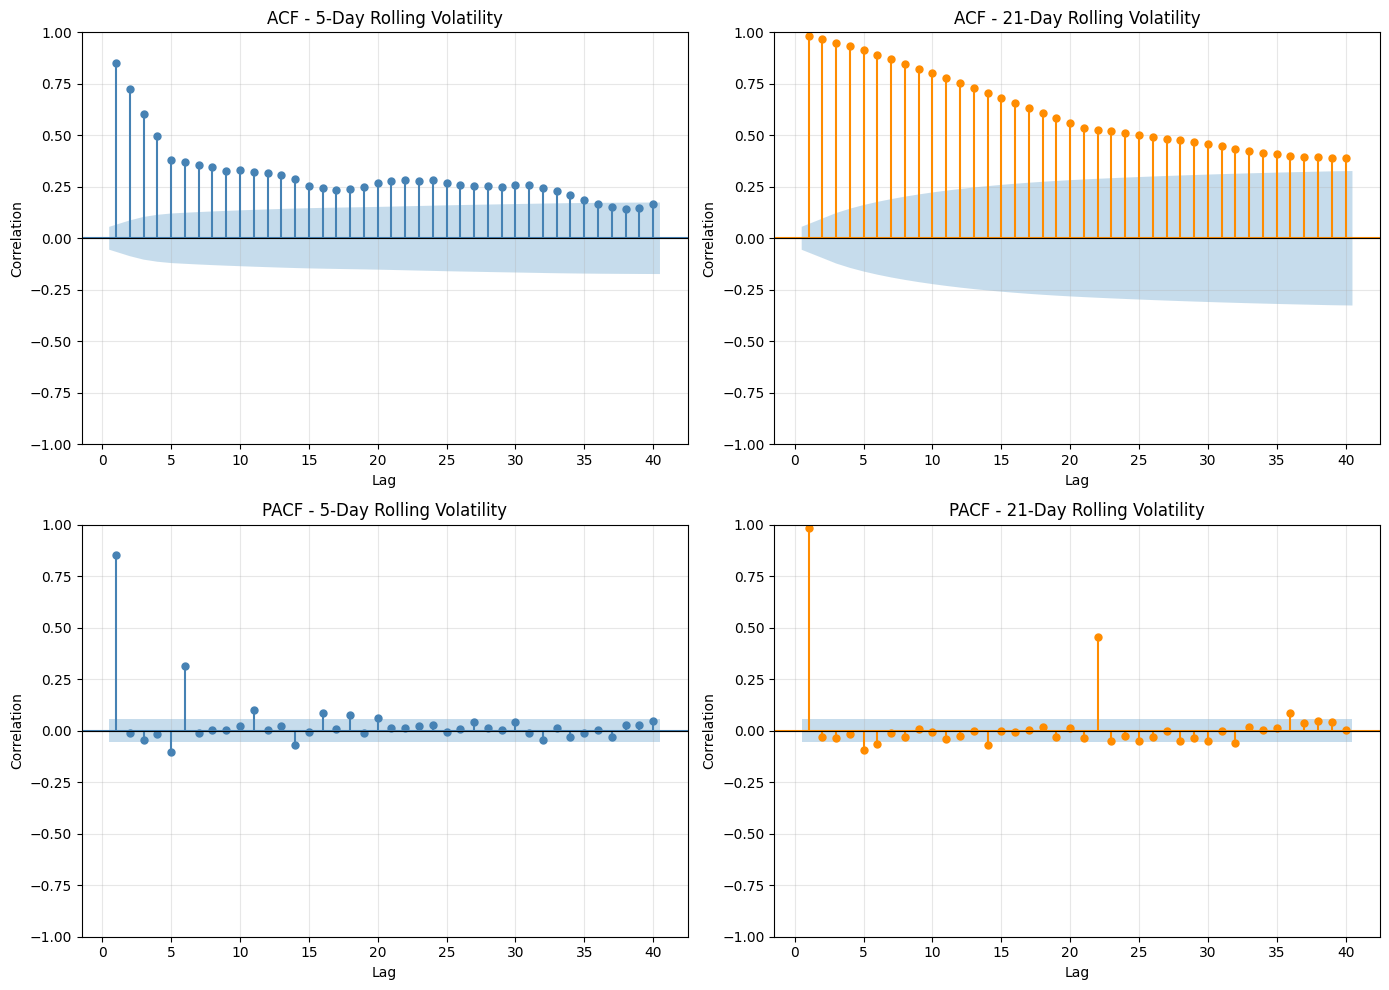

In [55]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

plot_acf(returns['Vol_5'].dropna(), lags=40, zero=False,
         ax=axes[0][0], title='ACF - 5-Day Rolling Volatility',
         alpha=0.05, color='steelblue', vlines_kwargs={'colors': 'steelblue'})

plot_pacf(returns['Vol_5'].dropna(), lags=40, zero=False,
          ax=axes[1][0], title='PACF - 5-Day Rolling Volatility',
          alpha=0.05, color='steelblue', vlines_kwargs={'colors': 'steelblue'})

plot_acf(returns['Vol_21'].dropna(), lags=40, zero=False,
         ax=axes[0][1], title='ACF - 21-Day Rolling Volatility',
         alpha=0.05, color='darkorange', vlines_kwargs={'colors': 'darkorange'})

plot_pacf(returns['Vol_21'].dropna(), lags=40, zero=False,
          ax=axes[1][1], title='PACF - 21-Day Rolling Volatility',
          alpha=0.05, color='darkorange', vlines_kwargs={'colors': 'darkorange'})

for ax in axes.flatten():
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Lag')
    ax.set_ylabel('Correlation')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('output/acf_pacf_volatility.png', dpi=150)
plt.show()

## Key Observation: Volatility Clustering & Its Implication for DNEM

Unlike the portfolio daily return series (which shows no autocorrelation), 
both the 5-day and 21-day rolling volatility series exhibit strong and persistent autocorrelation.

**5-Day Volatility:** ACF decays slowly across 15+ significant lags; 
PACF shows a dominant AR(1) structure (lag-1 coefficient ≈ 0.85), 
with a minor secondary spike at lag=6.

**21-Day Volatility:** Even stronger persistence, with nearly all 40 lags significant in ACF; 
PACF confirms AR(1) dominance (lag-1 ≈ 1.0), with a mechanical spike at lag=22 
likely attributable to the rolling window construction.

**Core Finding:** Returns have no memory. Volatility does.  
This is consistent with the well-established **volatility clustering effect** — 
large moves tend to follow large moves, and calm periods tend to persist.

**Implication for DNEM:**  
Volatility state should be incorporated as a third conditioning variable alongside 
sentiment score and article volume. Specifically, when high news sentiment coincides 
with elevated volatility (Vol_5 above threshold), the next-day return distribution 
is expected to have both a stronger directional bias and a wider prediction interval.  
The 5-day rolling volatility (Vol_5) serves as the real-time volatility proxy, 
enabling dynamic adjustment of prediction interval width based on current market regime.

| Current State | Prediction |
|--------------|------------|
| High sentiment + High volatility | Large upward move, wide interval |
| High sentiment + Low volatility  | Moderate upward move, narrow interval |
| Low sentiment + High volatility  | Large downward move, wide interval |
| Low sentiment + Low volatility   | Weak signal, no prediction issued |

In [56]:
# Daily article count per ticker
news_daily = {}
for ticker, df in news.items():
    daily = df.groupby(df['Date'].dt.date).size().reset_index()
    daily.columns = ['Date', 'Article_Count']
    daily['Date'] = pd.to_datetime(daily['Date'])
    news_daily[ticker] = daily
    print(f"{ticker}: {len(daily)} days with news, avg {daily['Article_Count'].mean():.1f} articles/day")

NVDA: 605 days with news, avg 4.0 articles/day
META: 845 days with news, avg 2.9 articles/day
MSFT: 954 days with news, avg 2.8 articles/day
AMZN: 1258 days with news, avg 3.2 articles/day
GOOGL: 772 days with news, avg 2.1 articles/day


In [57]:
for ticker, df in news_daily.items():
    print(f"{ticker}: mean={df['Article_Count'].mean():.1f}, median={df['Article_Count'].median():.1f}")

NVDA: mean=4.0, median=2.0
META: mean=2.9, median=2.0
MSFT: mean=2.8, median=2.0
AMZN: mean=3.2, median=2.0
GOOGL: mean=2.1, median=1.0


In [59]:
print(type(stocks['NVDA']['Date'].iloc[0]))
print(type(news_daily['NVDA']['Date'].iloc[0]))
print(stocks['NVDA']['Date'].iloc[0])
print(news_daily['NVDA']['Date'].iloc[0])

<class 'pandas.Timestamp'>
<class 'pandas.Timestamp'>
2021-01-04 05:00:00
2021-01-06 00:00:00


In [60]:
for ticker in stocks:
    stocks[ticker]['Date'] = stocks[ticker]['Date'].dt.normalize()

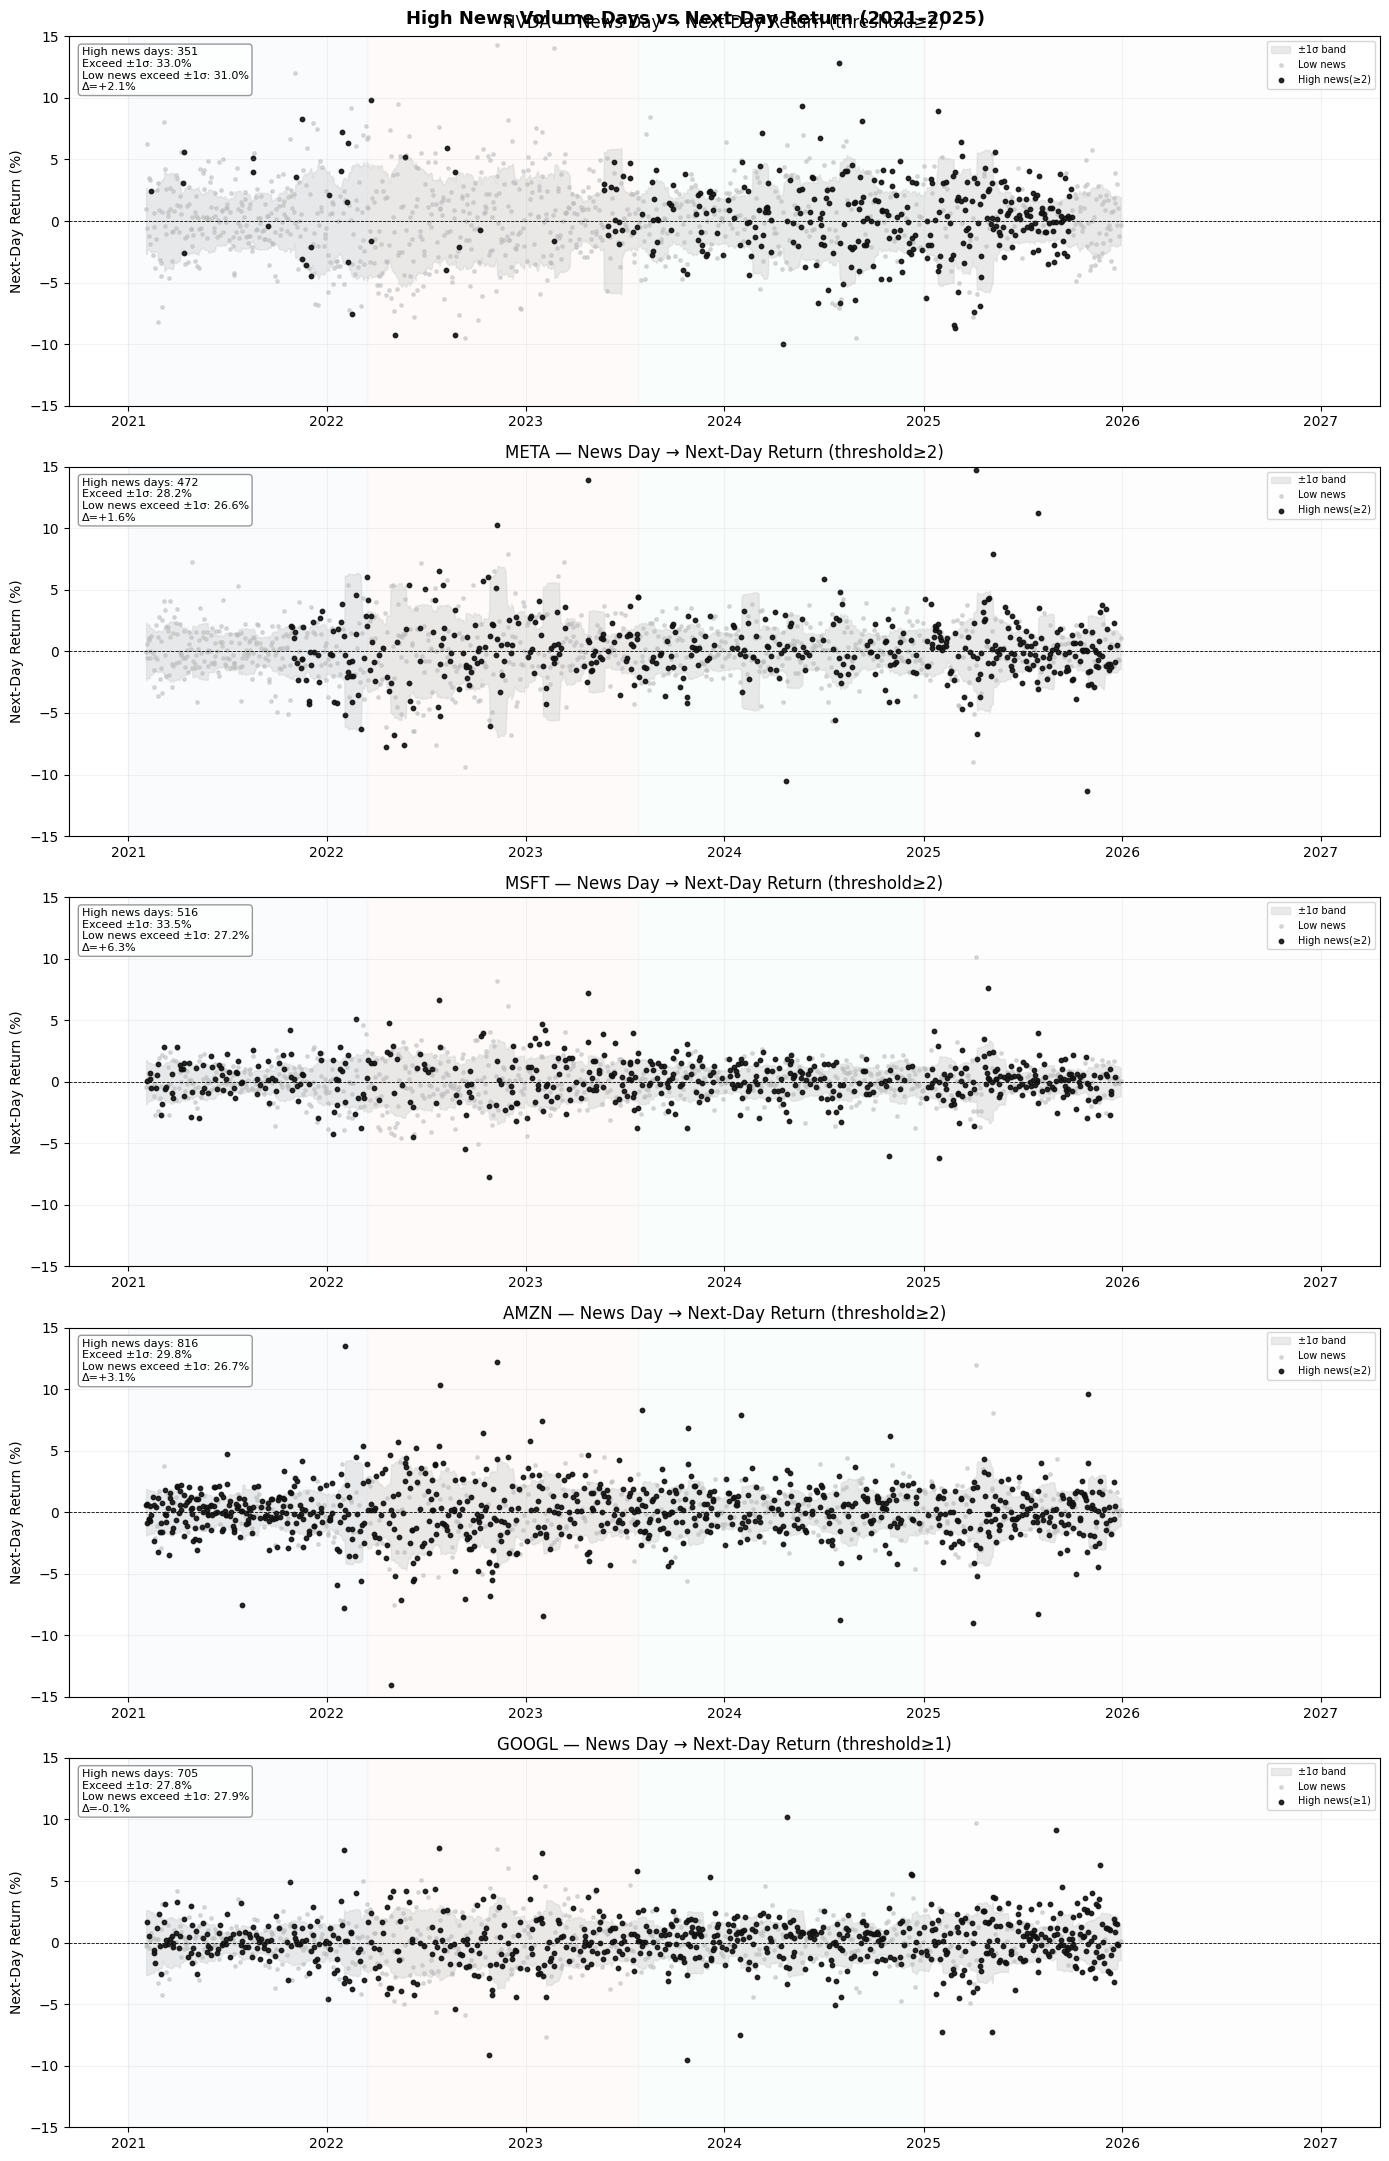

In [61]:
thresholds = {'NVDA': 2, 'META': 2, 'MSFT': 2, 'AMZN': 2, 'GOOGL': 1}

fig, axes = plt.subplots(5, 1, figsize=(14, 22), facecolor='white')

for i, ticker in enumerate(['NVDA', 'META', 'MSFT', 'AMZN', 'GOOGL']):
    ax = axes[i]
    ax.set_facecolor('white')

    st = stocks[ticker][['Date', 'Daily_Return']].copy()
    st['Daily_Return'] = st['Daily_Return'] * 100
    # 次日收益率：新闻日t → 收益率t+1
    st['next_ret'] = st['Daily_Return'].shift(-1)
    st['rolling_std'] = st['Daily_Return'].rolling(21).std()
    
    # 合并新闻量（当天文章数对应次日收益）
    st = st.merge(news_daily[ticker], on='Date', how='left')
    st['Article_Count'] = st['Article_Count'].fillna(0)
    st = st.dropna(subset=['next_ret', 'rolling_std'])

    high = st[st['Article_Count'] >= thresholds[ticker]]
    low  = st[st['Article_Count'] <  thresholds[ticker]]

    for phase, (start, end) in phase_bounds.items():
        ax.axvspan(pd.Timestamp(start), pd.Timestamp(end),
                   alpha=0.12, color=phase_colors[phase])

    ax.fill_between(st['Date'], -st['rolling_std'], st['rolling_std'],
                    color='#cccccc', alpha=0.4, label='±1σ band')
    ax.axhline(0, color='black', linewidth=0.6, linestyle='--')
    
    ax.scatter(low['Date'],  low['next_ret'],  color='#bbbbbb', alpha=0.5, s=6, label='Low news')
    ax.scatter(high['Date'], high['next_ret'], color='#111111', alpha=0.9, s=10, label=f'High news(≥{thresholds[ticker]})')

    pct_h = (high['next_ret'].abs() > high['rolling_std']).mean() * 100
    pct_l = (low['next_ret'].abs()  > low['rolling_std']).mean()  * 100
    ax.text(0.01, 0.97,
            f'High news days: {len(high)}\nExceed ±1σ: {pct_h:.1f}%\nLow news exceed ±1σ: {pct_l:.1f}%\nΔ={pct_h-pct_l:+.1f}%',
            transform=ax.transAxes, fontsize=8, va='top',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))

    ax.set_ylim(-15, 15)
    ax.set_title(f'{ticker} — News Day → Next-Day Return (threshold≥{thresholds[ticker]})')
    ax.set_ylabel('Next-Day Return (%)')
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.legend(loc='upper right', fontsize=7)
    ax.grid(True, alpha=0.15)

plt.suptitle('High News Volume Days vs Next-Day Return (2021–2025)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('output/news_coverage.png', dpi=150, facecolor='white', bbox_inches='tight')
plt.show()

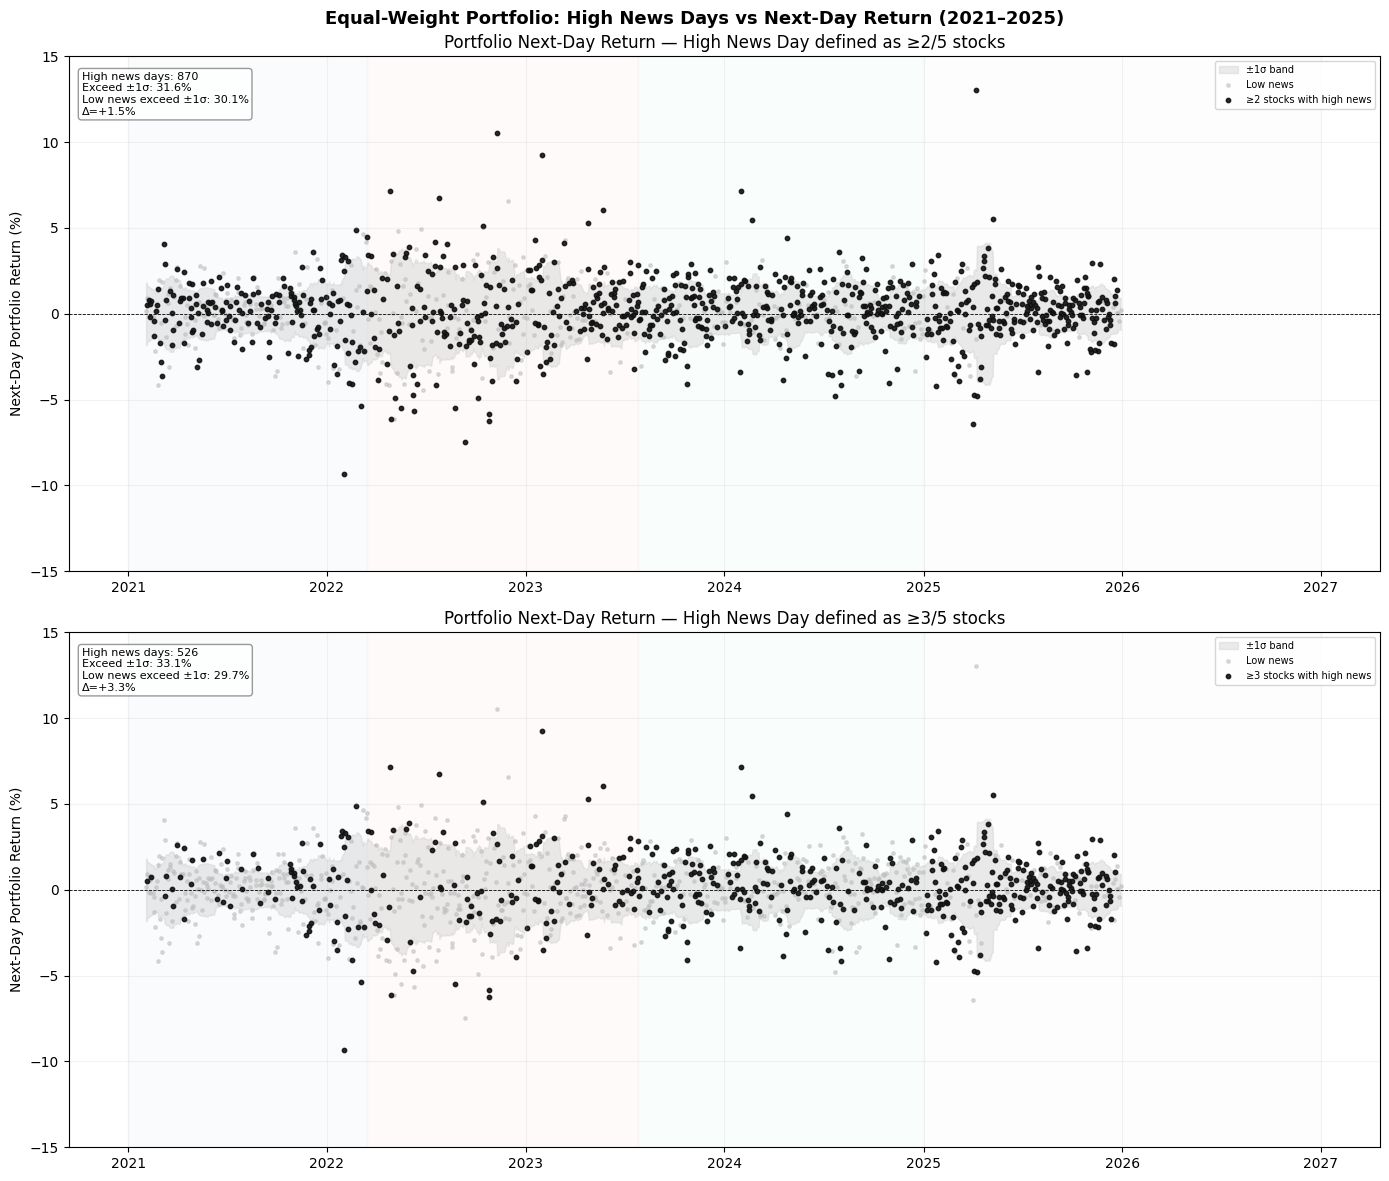

In [62]:
fig, axes = plt.subplots(2, 1, figsize=(14, 12), facecolor='white')

# Daily threshold check: whether each stock meets its article count threshold
coverage = pd.DataFrame({'Date': returns['Date']})
for ticker in ['NVDA', 'META', 'MSFT', 'AMZN', 'GOOGL']:
    nd = news_daily[ticker].copy()
    nd[ticker] = (nd['Article_Count'] >= thresholds[ticker]).astype(int)
    coverage = coverage.merge(nd[['Date', ticker]], on='Date', how='left')
    coverage[ticker] = coverage[ticker].fillna(0)

coverage['count'] = coverage[['NVDA','META','MSFT','AMZN','GOOGL']].sum(axis=1)
coverage = coverage.merge(returns[['Date','Portfolio']], on='Date', how='left')
coverage['next_ret'] = coverage['Portfolio'].shift(-1)
coverage['rolling_std'] = coverage['Portfolio'].rolling(21).std()
coverage = coverage.dropna(subset=['next_ret', 'rolling_std'])

for ax, min_count in zip(axes, [2, 3]):
    high = coverage[coverage['count'] >= min_count]
    low  = coverage[coverage['count'] <  min_count]

    for phase, (start, end) in phase_bounds.items():
        ax.axvspan(pd.Timestamp(start), pd.Timestamp(end),
                   alpha=0.12, color=phase_colors[phase])

    ax.fill_between(coverage['Date'], -coverage['rolling_std'], coverage['rolling_std'],
                    color='#cccccc', alpha=0.4, label='±1σ band')
    ax.axhline(0, color='black', linewidth=0.6, linestyle='--')
    ax.scatter(low['Date'],  low['next_ret'],  color='#bbbbbb', alpha=0.5, s=6, label='Low news')
    ax.scatter(high['Date'], high['next_ret'], color='#111111', alpha=0.9, s=10,
               label=f'≥{min_count} stocks with high news')

    pct_h = (high['next_ret'].abs() > high['rolling_std']).mean() * 100
    pct_l = (low['next_ret'].abs()  > low['rolling_std']).mean()  * 100
    ax.text(0.01, 0.97,
            f'High news days: {len(high)}\nExceed ±1σ: {pct_h:.1f}%\nLow news exceed ±1σ: {pct_l:.1f}%\nΔ={pct_h-pct_l:+.1f}%',
            transform=ax.transAxes, fontsize=8, va='top',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))

    ax.set_ylim(-15, 15)
    ax.set_title(f'Portfolio Next-Day Return — High News Day defined as ≥{min_count}/5 stocks')
    ax.set_ylabel('Next-Day Portfolio Return (%)')
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.legend(loc='upper right', fontsize=7)
    ax.grid(True, alpha=0.15)

plt.suptitle('Equal-Weight Portfolio: High News Days vs Next-Day Return (2021–2025)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('output/portfolio_news_coverage.png', dpi=150, facecolor='white', bbox_inches='tight')
plt.show()

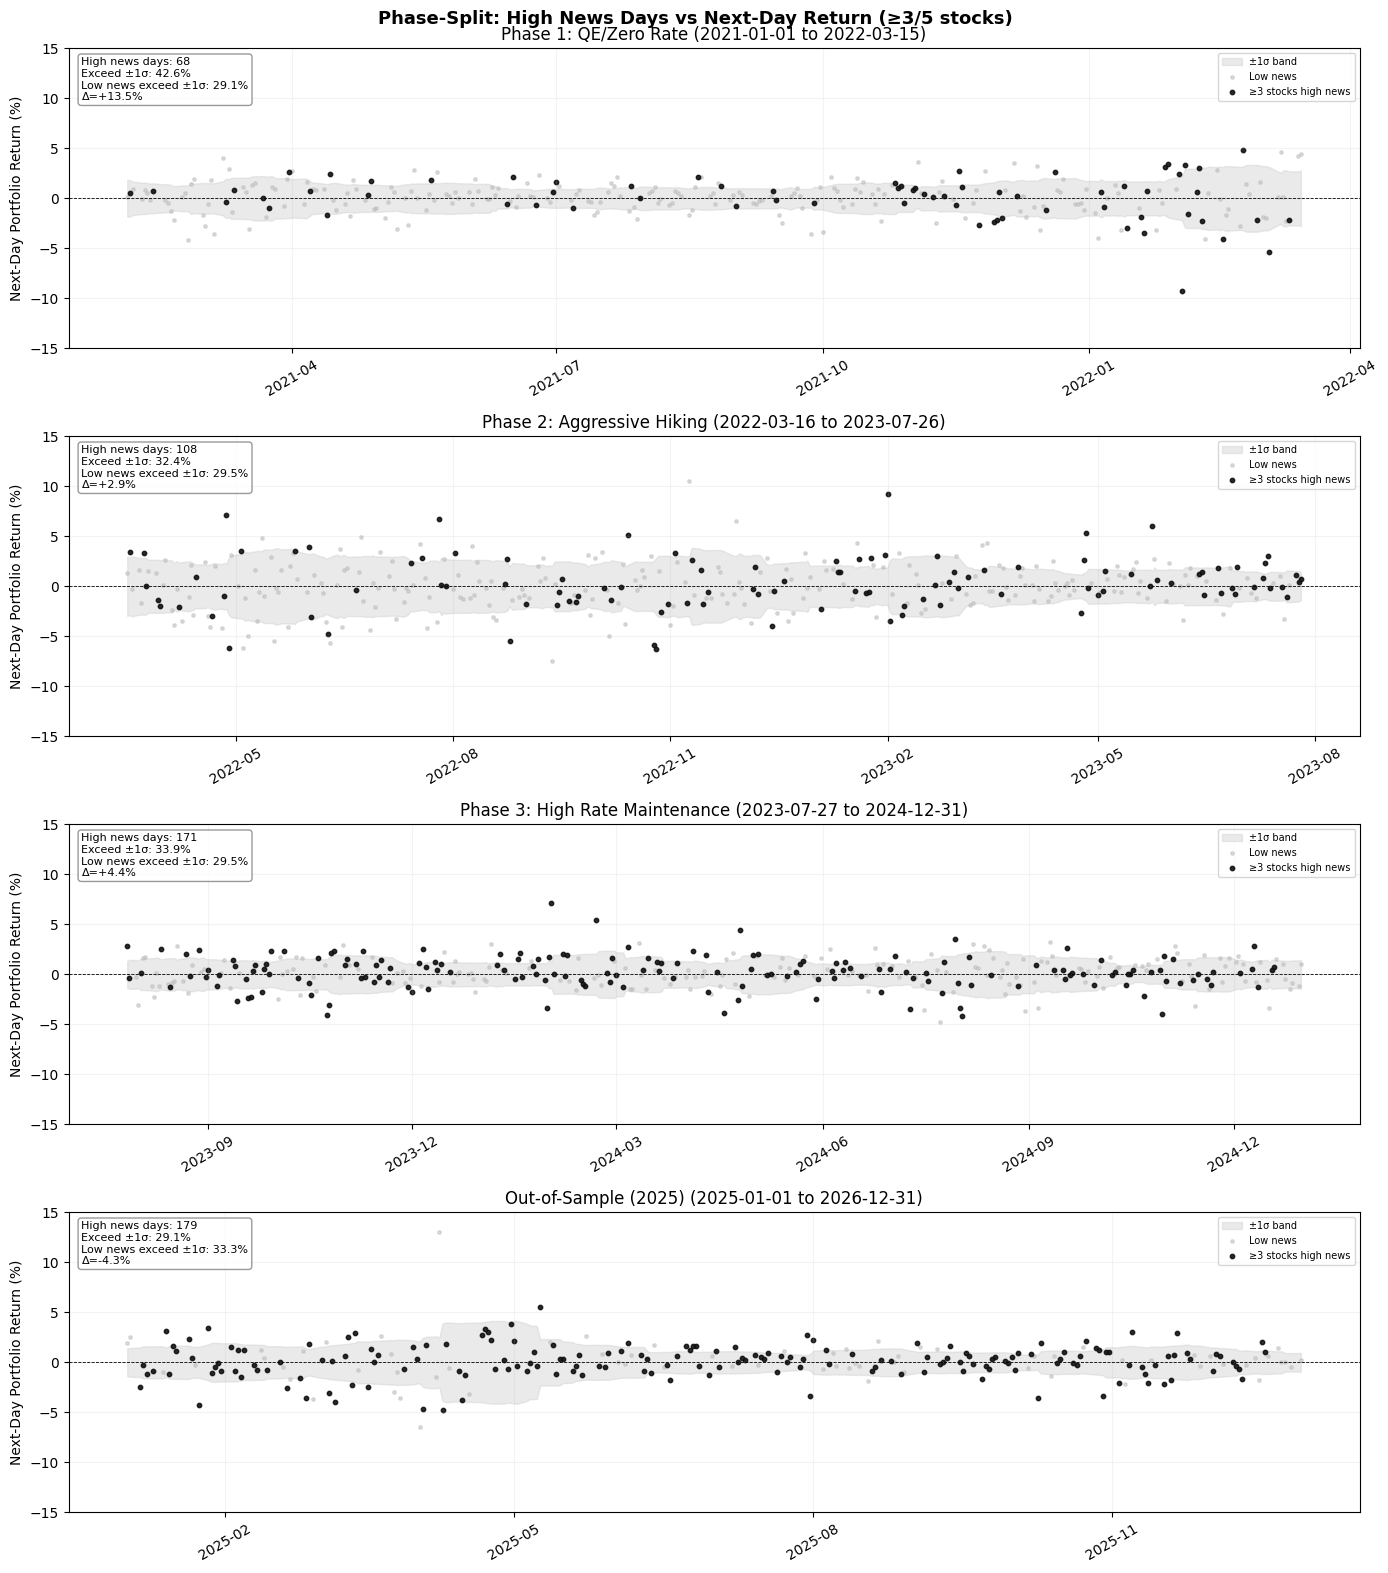

In [66]:
fig, axes = plt.subplots(4, 1, figsize=(14, 16), facecolor='white')

phase_ranges = {
    'Phase 1: QE/Zero Rate':        ('2021-01-01', '2022-03-15'),
    'Phase 2: Aggressive Hiking':   ('2022-03-16', '2023-07-26'),
    'Phase 3: High Rate Maintenance': ('2023-07-27', '2024-12-31'),
    'Out-of-Sample (2025)':           ('2025-01-01', '2026-12-31'),
}

for ax, (phase, (start, end)) in zip(axes, phase_ranges.items()):
    mask = (coverage['Date'] >= start) & (coverage['Date'] <= end)
    df = coverage[mask].copy()
    
    high = df[df['count'] >= 3]
    low  = df[df['count'] <  3]

    ax.fill_between(df['Date'], -df['rolling_std'], df['rolling_std'],
                    color='#cccccc', alpha=0.4, label='±1σ band')
    ax.axhline(0, color='black', linewidth=0.6, linestyle='--')
    ax.scatter(low['Date'],  low['next_ret'],  color='#bbbbbb', alpha=0.5, s=6, label='Low news')
    ax.scatter(high['Date'], high['next_ret'], color='#111111', alpha=0.9, s=10, label='≥3 stocks high news')

    pct_h = (high['next_ret'].abs() > high['rolling_std']).mean() * 100 if len(high) > 0 else 0
    pct_l = (low['next_ret'].abs()  > low['rolling_std']).mean()  * 100 if len(low) > 0 else 0
    ax.text(0.01, 0.97,
            f'High news days: {len(high)}\nExceed ±1σ: {pct_h:.1f}%\nLow news exceed ±1σ: {pct_l:.1f}%\nΔ={pct_h-pct_l:+.1f}%',
            transform=ax.transAxes, fontsize=8, va='top',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))

    ax.set_ylim(-15, 15)
    ax.set_title(f'{phase} ({start} to {end})')
    ax.set_ylabel('Next-Day Portfolio Return (%)')
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.legend(loc='upper right', fontsize=7)
    ax.grid(True, alpha=0.15)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

plt.suptitle('Phase-Split: High News Days vs Next-Day Return (≥3/5 stocks)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('output/phase_news_coverage.png', dpi=150, facecolor='white', bbox_inches='tight')
plt.show()

In [67]:
for phase, (start, end) in phase_ranges.items():
    mask = (coverage['Date'] >= start) & (coverage['Date'] <= end)
    df = coverage[mask].copy()
    
    high = df[df['count'] >= 3]
    
    total_exceed = (df['next_ret'].abs() > df['rolling_std']).sum()
    high_exceed  = (high['next_ret'].abs() > high['rolling_std']).sum()
    
    ratio = high_exceed / total_exceed * 100 if total_exceed > 0 else 0
    print(f"{phase}: high news exceed={high_exceed}, total exceed={total_exceed}, ratio={ratio:.1f}%")

Phase 1: QE/Zero Rate: high news exceed=29, total exceed=91, ratio=31.9%
Phase 2: Aggressive Hiking: high news exceed=35, total exceed=104, ratio=33.7%
Phase 3: High Rate Maintenance: high news exceed=58, total exceed=114, ratio=50.9%
Out-of-Sample (2025): high news exceed=52, total exceed=75, ratio=69.3%


## Key Finding: News Contribution to Portfolio Volatility by Monetary Phase

We define "high news days" as days when ≥3/5 stocks simultaneously meet their 
individual article count thresholds (median-based). A return is considered an 
"excess move" when the next-day portfolio return exceeds the 21-day rolling ±1σ band.

The key metric is: **high news days' share of total excess moves per phase.**

| Phase | Period | High News Days | High News Exceed ±1σ | Total Exceed ±1σ | Ratio |
|-------|--------|---------------|----------------------|------------------|-------|
| Phase 1: QE/Zero Rate | 2021-01 ~ 2022-03 | 68 | 29 | 91 | 31.9% |
| Phase 2: Aggressive Hiking | 2022-03 ~ 2023-07 | 108 | 35 | 104 | 33.7% |
| Phase 3: High Rate Maintenance | 2023-07 ~ 2024-12 | 171 | 58 | 114 | 50.9% |
| Out-of-Sample (2025) | 2025-01 ~ 2025-12 | 179 | 52 | 75 | 69.3% |

**Core Finding:** The news contribution ratio increases monotonically across phases — 
from ~32% in the QE era to ~69% in 2025. This reflects a structural regime shift: 
as monetary policy stabilized, AI narrative shocks progressively replaced interest 
rate changes as the dominant driver of portfolio volatility.

**Implication for DNEM:** This finding provides the strongest EDA-level